### =============================================================================================================================================================================
# Step 1 : Import Required Libraries
### =============================================================================================================================================================================

In [10]:
# ===============================
# Data Manipulation Libraries
# ===============================

import pandas as pd
import numpy as np

# ===============================
# Data Visualization Libraries
# ===============================

import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# Machine Learning Utilities
# ===============================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error
)

# ===============================
# Ignore Warning Messages
# ===============================

import warnings
warnings.filterwarnings("ignore")

### ==============================================================================================================================================================================
# **Step 2 : Define Project Paths**
### ==============================================================================================================================================================================

In [11]:
from pathlib import Path

print(Path.cwd())

c:\Users\Lenovo\OneDrive\Desktop\Smart-City-Traffic-Forecasting\notebooks


In [12]:
# ======================================
# Project Root Directory
# ======================================

PROJECT_ROOT = Path.cwd().parent

print(PROJECT_ROOT)

c:\Users\Lenovo\OneDrive\Desktop\Smart-City-Traffic-Forecasting


In [13]:
# ======================================
# Data Directory
# ======================================

DATA_DIR = PROJECT_ROOT / "data"

print(DATA_DIR)

c:\Users\Lenovo\OneDrive\Desktop\Smart-City-Traffic-Forecasting\data


### =============================================================================================================================================================================
# **Step 3 : Load Dataset**
### ============================================================================================================================================================================

In [14]:
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"

print(TRAIN_PATH)
print(TEST_PATH)

c:\Users\Lenovo\OneDrive\Desktop\Smart-City-Traffic-Forecasting\data\train.csv
c:\Users\Lenovo\OneDrive\Desktop\Smart-City-Traffic-Forecasting\data\test.csv


In [15]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print(train_df.shape)
print(test_df.shape)

(48120, 4)
(11808, 3)


In [16]:
# ======================================
# Step 4 : Display First Five Rows
# ======================================

train_df.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [17]:
print("Training Shape :", train_df.shape)

print("Testing Shape :", test_df.shape)

Training Shape : (48120, 4)
Testing Shape : (11808, 3)


In [18]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   DateTime  48120 non-null  str  
 1   Junction  48120 non-null  int64
 2   Vehicles  48120 non-null  int64
 3   ID        48120 non-null  int64
dtypes: int64(3), str(1)
memory usage: 1.5 MB


In [19]:
# ======================================
# Step 5 : Check Data Types
# ======================================

train_df.dtypes

DateTime      str
Junction    int64
Vehicles    int64
ID          int64
dtype: object

In [20]:
# ======================================
# Step 6 : Check Missing Values
# ======================================

train_df.isnull().sum()

DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64

In [21]:
# ======================================
# Step 7 : Check Duplicate Records
# ======================================

train_df.duplicated().sum()

np.int64(0)

In [22]:
# ======================================
# Step 8 : Unique Values
# ======================================

train_df.nunique()

DateTime    14592
Junction        4
Vehicles      141
ID          48120
dtype: int64

In [23]:
# ======================================
# Step 9 : Statistical Summary
# ======================================

train_df.describe()

,Junction,Vehicles,ID
count,48120.000000,48120.000000,4.812000e+04
mean,2.180549,22.791334,2.016330e+10
std,0.966955,20.750063,5.944854e+06
min,1.000000,1.000000,2.015110e+10
25%,1.000000,9.000000,2.016042e+10
50%,2.000000,15.000000,2.016093e+10
75%,3.000000,29.000000,2.017023e+10
max,4.000000,180.000000,2.017063e+10


In [24]:
# ======================================
# Step 10 : Memory Usage
# ======================================

train_df.memory_usage(deep=True)

Index           132
DateTime    3272160
Junction     384960
Vehicles     384960
ID           384960
dtype: int64

In [ ]:
'''
# ======================================
# Step 5 : Data Inspection
# ======================================

print("=" * 60)
print("DATA TYPES")
print("=" * 60)
display(train_df.dtypes)

print("=" * 60)
print("MISSING VALUES")
print("=" * 60)
display(train_df.isnull().sum())

print("=" * 60)
print("DUPLICATE RECORDS")
print("=" * 60)
print(train_df.duplicated().sum())

print("=" * 60)
print("UNIQUE VALUES")
print("=" * 60)
display(train_df.nunique())

print("=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)
display(train_df.describe())

print("=" * 60)
print("MEMORY USAGE")
print("=" * 60)
display(train_df.memory_usage(deep=True))

'''

In [27]:
# ======================================
# Step 11 : Convert DateTime Column
# ======================================

train_df["DateTime"] = pd.to_datetime(train_df["DateTime"])

test_df["DateTime"] = pd.to_datetime(test_df["DateTime"])


train_df.dtypes
train_df["DateTime"].dt.year

0        2015
1        2015
2        2015
3        2015
4        2015
         ... 
48115    2017
48116    2017
48117    2017
48118    2017
48119    2017
Name: DateTime, Length: 48120, dtype: int32

In [33]:
# ======================================
# Step 11 : Convert DateTime
# ======================================

train_df["DateTime"] = pd.to_datetime(train_df["DateTime"])
test_df["DateTime"] = pd.to_datetime(test_df["DateTime"])

# ======================================
# Step 12 : Extract Time Features
# ======================================

train_df["Year"] = train_df["DateTime"].dt.year
test_df["Year"] = test_df["DateTime"].dt.year

train_df["Month"] = train_df["DateTime"].dt.month
test_df["Month"] = test_df["DateTime"].dt.month

train_df["Day"] = train_df["DateTime"].dt.day
test_df["Day"] = test_df["DateTime"].dt.day

train_df["Hour"] = train_df["DateTime"].dt.hour
test_df["Hour"] = test_df["DateTime"].dt.hour

# ======================================
# Step 13 : Verify
# ======================================

print(train_df.dtypes)

train_df.head()

DateTime    datetime64[us]
Junction             int64
Vehicles             int64
ID                   int64
Year                 int32
Month                int32
Day                  int32
Hour                 int32
dtype: object


,DateTime,Junction,Vehicles,ID,Year,Month,Day,Hour
0,2015-11-01 00:00:00,1,15,20151101001,2015,11,1,0
1,2015-11-01 01:00:00,1,13,20151101011,2015,11,1,1
2,2015-11-01 02:00:00,1,10,20151101021,2015,11,1,2
3,2015-11-01 03:00:00,1,7,20151101031,2015,11,1,3
4,2015-11-01 04:00:00,1,9,20151101041,2015,11,1,4


In [34]:
# ======================================
# Step 14 : Day of Week
# ======================================

train_df["DayOfWeek"] = train_df["DateTime"].dt.dayofweek
test_df["DayOfWeek"] = test_df["DateTime"].dt.dayofweek

In [35]:
# ======================================
# Step 15 : Day Name
# ======================================

train_df["DayName"] = train_df["DateTime"].dt.day_name()

test_df["DayName"] = test_df["DateTime"].dt.day_name()

In [36]:
# ======================================
# Step 16 : Week Number
# ======================================

train_df["WeekOfYear"] = train_df["DateTime"].dt.isocalendar().week.astype(int)

test_df["WeekOfYear"] = test_df["DateTime"].dt.isocalendar().week.astype(int)

In [37]:
# ======================================
# Step 17 : Quarter
# ======================================

train_df["Quarter"] = train_df["DateTime"].dt.quarter

test_df["Quarter"] = test_df["DateTime"].dt.quarter

In [38]:
# ======================================
# Step 18 : Weekend
# ======================================

train_df["IsWeekend"] = (
    train_df["DayOfWeek"] >= 5
).astype(int)

test_df["IsWeekend"] = (
    test_df["DayOfWeek"] >= 5
).astype(int)

In [39]:
# Month Start

train_df["IsMonthStart"] = train_df["DateTime"].dt.is_month_start.astype(int)

test_df["IsMonthStart"] = test_df["DateTime"].dt.is_month_start.astype(int)

# month End

train_df["IsMonthEnd"] = train_df["DateTime"].dt.is_month_end.astype(int)

test_df["IsMonthEnd"] = test_df["DateTime"].dt.is_month_end.astype(int)

In [40]:
# Verify

train_df.head()

,DateTime,Junction,Vehicles,ID,Year,Month,Day,Hour,DayOfWeek,DayName,WeekOfYear,Quarter,IsWeekend,IsMonthStart,IsMonthEnd
0,2015-11-01 00:00:00,1,15,20151101001,2015,11,1,0,6,Sunday,44,4,1,1,0
1,2015-11-01 01:00:00,1,13,20151101011,2015,11,1,1,6,Sunday,44,4,1,1,0
2,2015-11-01 02:00:00,1,10,20151101021,2015,11,1,2,6,Sunday,44,4,1,1,0
3,2015-11-01 03:00:00,1,7,20151101031,2015,11,1,3,6,Sunday,44,4,1,1,0
4,2015-11-01 04:00:00,1,9,20151101041,2015,11,1,4,6,Sunday,44,4,1,1,0


In [41]:
# ======================================
# Phase 3 : Exploratory Data Analysis
# ======================================

# ======================================
# Step 19 : Distribution of Vehicles
# ======================================

train_df["Vehicles"].describe()

count    48120.000000
mean        22.791334
std         20.750063
min          1.000000
25%          9.000000
50%         15.000000
75%         29.000000
max        180.000000
Name: Vehicles, dtype: float64

In [42]:
print("Mean   :", train_df["Vehicles"].mean())
print("Median :", train_df["Vehicles"].median())
print("Mode   :", train_df["Vehicles"].mode()[0])
print("Minimum:", train_df["Vehicles"].min())
print("Maximum:", train_df["Vehicles"].max())

Mean   : 22.79133416458853
Median : 15.0
Mode   : 8
Minimum: 1
Maximum: 180


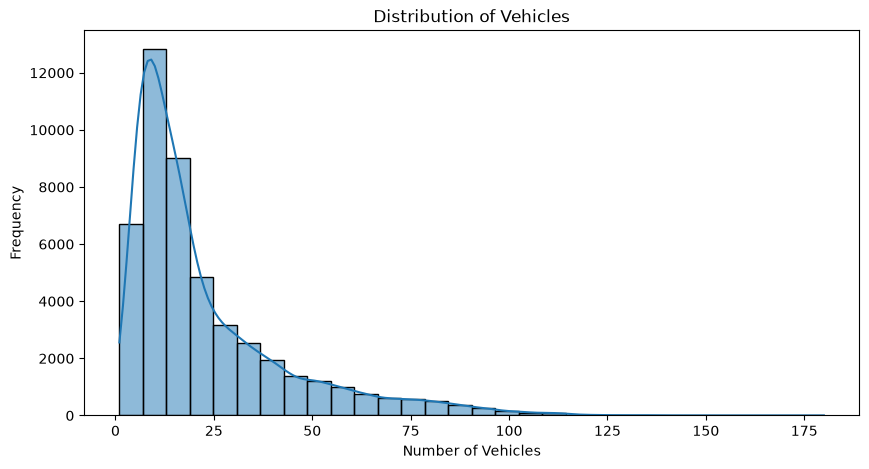

In [43]:
plt.figure(figsize=(10, 5))

sns.histplot(
    train_df["Vehicles"],
    bins=30,
    kde=True
)

plt.title("Distribution of Vehicles")
plt.xlabel("Number of Vehicles")
plt.ylabel("Frequency")

plt.show()

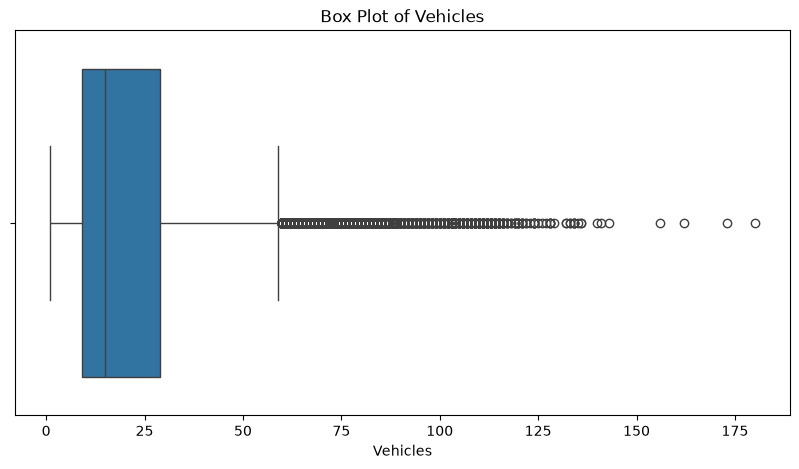

In [44]:
# ======================================
# Step 20 : Box Plot of Vehicles
# ======================================

plt.figure(figsize=(10,5))

sns.boxplot(
    x=train_df["Vehicles"]
)

plt.title("Box Plot of Vehicles")

plt.xlabel("Vehicles")

plt.show()

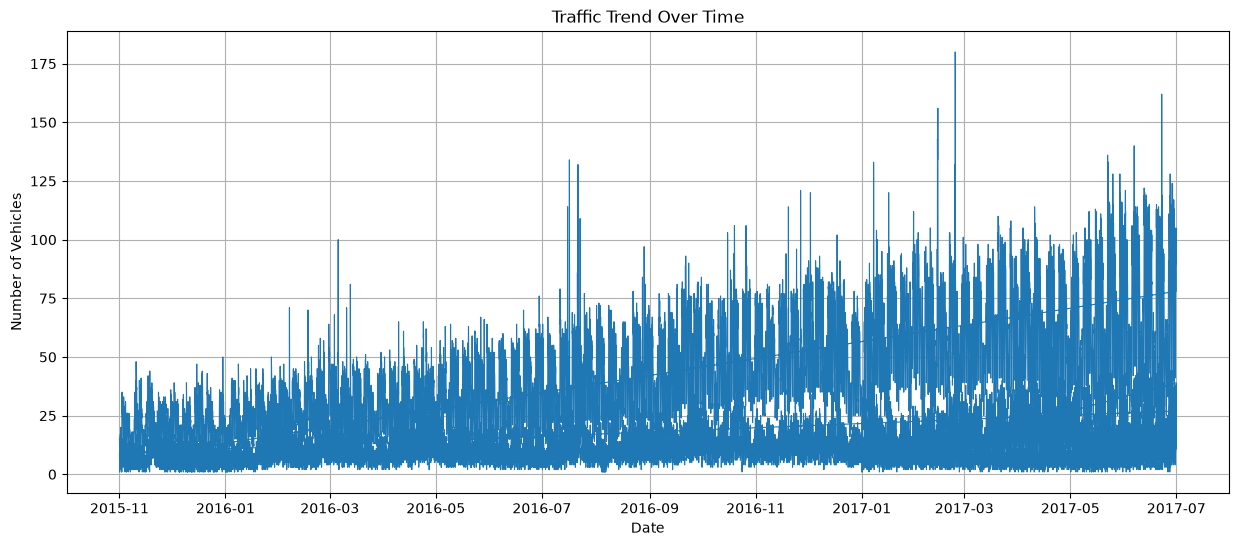

In [45]:
# ======================================
# Step 21 : Traffic Trend Over Time
# ======================================

plt.figure(figsize=(15, 6))

plt.plot(
    train_df["DateTime"],
    train_df["Vehicles"],
    linewidth=0.8
)

plt.title("Traffic Trend Over Time")

plt.xlabel("Date")

plt.ylabel("Number of Vehicles")

plt.grid(True)

plt.show()

In [47]:
# ======================================
# Step 22 : Average Traffic by Junction
# ======================================

junction_avg = (
    train_df
    .groupby("Junction")["Vehicles"]
    .mean()
    .reset_index()
)

display(junction_avg)

,Junction,Vehicles
0,1,45.052906
1,2,14.253221
2,3,13.694010
3,4,7.251611


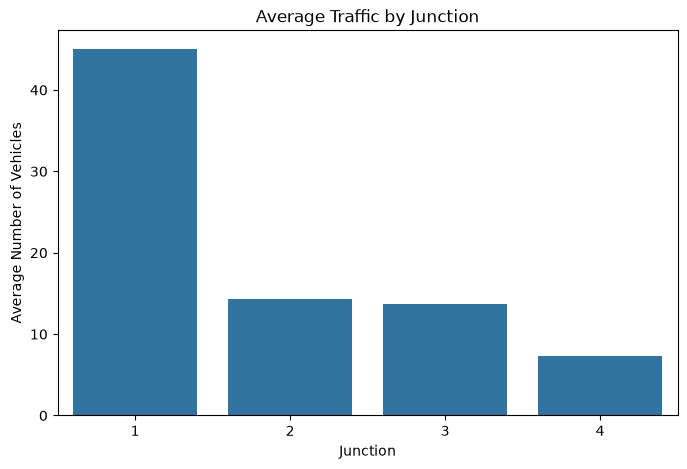

In [48]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=junction_avg,
    x="Junction",
    y="Vehicles"
)

plt.title("Average Traffic by Junction")
plt.xlabel("Junction")
plt.ylabel("Average Number of Vehicles")

plt.show()

In [49]:
# ======================================
# Step 24 : Average Traffic by Hour
# ======================================

hourly_traffic = (
    train_df
    .groupby("Hour")["Vehicles"]
    .mean()
    .reset_index()
)

display(hourly_traffic)

,Hour,Vehicles
0,0,23.540648
1,1,19.654863
2,2,17.102743
3,3,14.847382
4,4,12.973067
5,5,12.173566
6,6,12.980050
7,7,14.703242
8,8,16.402993
9,9,19.379551


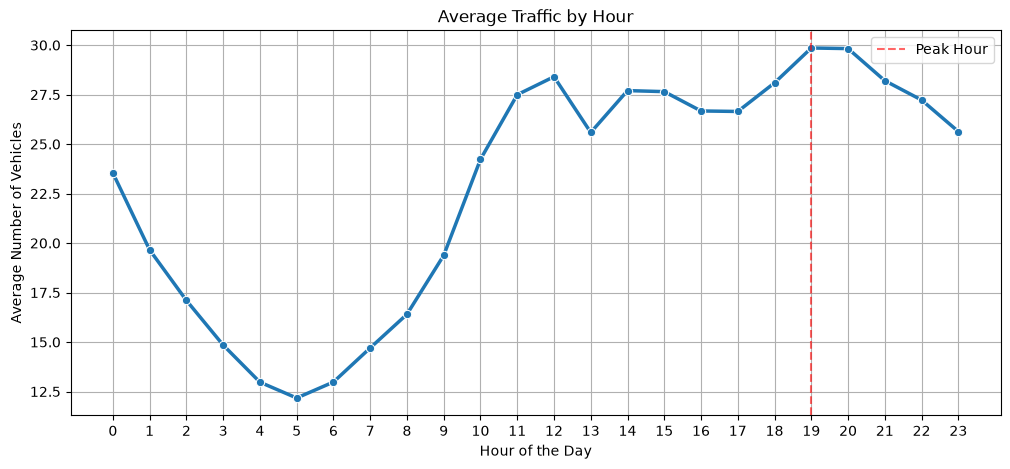

In [51]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=hourly_traffic,
    x="Hour",
    y="Vehicles",
    marker="o",
    linewidth=2.5
)

plt.axvline(x=19, color="red", linestyle="--", alpha=0.6, label="Peak Hour")
plt.legend()

plt.title("Average Traffic by Hour")

plt.xlabel("Hour of the Day")

plt.ylabel("Average Number of Vehicles")

plt.xticks(range(24))

plt.grid(True)

plt.show()

In [52]:
# ======================================
# Step 26 : Average Traffic by Day
# ======================================

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_traffic = (
    train_df
    .groupby("DayName")["Vehicles"]
    .mean()
    .reindex(day_order)
    .reset_index()
)

display(daily_traffic)

,DayName,Vehicles
0,Monday,24.409408
1,Tuesday,25.286731
2,Wednesday,25.149681
3,Thursday,25.152875
4,Friday,23.802120
5,Saturday,18.544611
6,Sunday,17.134727


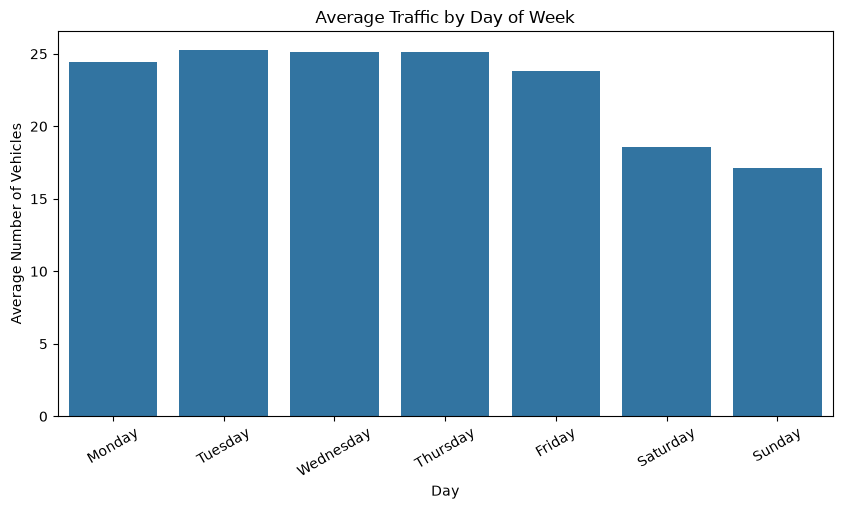

In [53]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=daily_traffic,
    x="DayName",
    y="Vehicles"
)

plt.title("Average Traffic by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Number of Vehicles")

plt.xticks(rotation=30)

plt.show()

In [54]:
# ======================================
# Step 28 : Average Traffic by Month
# ======================================

month_names = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

monthly_traffic = (
    train_df
    .groupby("Month")["Vehicles"]
    .mean()
    .reset_index()
)

monthly_traffic["MonthName"] = (
    monthly_traffic["Month"]
    .map(month_names)
)

display(monthly_traffic)

,Month,Vehicles,MonthName
0,1,19.727343,January
1,2,22.962312,February
2,3,23.073349,March
3,4,24.454365,April
4,5,24.633449,May
5,6,26.032143,June
6,7,21.837814,July
7,8,21.936380,August
8,9,25.644907,September
9,10,26.551075,October


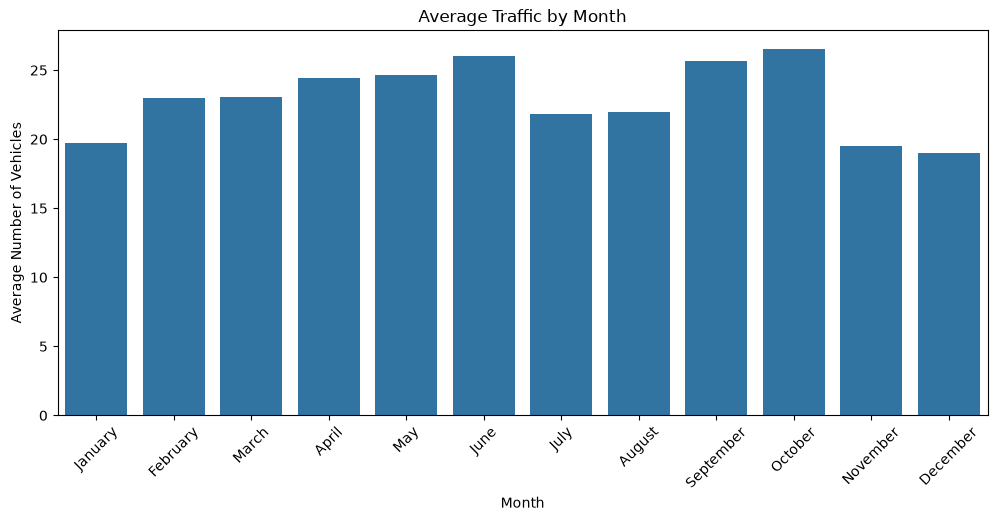

In [55]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=monthly_traffic,
    x="MonthName",
    y="Vehicles"
)

plt.title("Average Traffic by Month")
plt.xlabel("Month")
plt.ylabel("Average Number of Vehicles")

plt.xticks(rotation=45)

plt.show()

In [56]:
# ======================================
# Step 30 : Correlation Matrix
# ======================================

corr_df = train_df.drop(columns=["DateTime", "DayName"])

correlation = corr_df.corr(numeric_only=True)

correlation

,Junction,Vehicles,ID,Year,Month,Day,Hour,DayOfWeek,WeekOfYear,Quarter,IsWeekend,IsMonthStart,IsMonthEnd
Junction,1.000000e+00,-0.613787,0.221876,2.212977e-01,-1.242771e-01,-2.094621e-03,-2.132575e-15,-6.590970e-04,-1.231554e-01,-1.277047e-01,-1.043690e-03,2.422323e-04,2.422323e-04
Vehicles,-6.137872e-01,1.000000,0.227974,2.212531e-01,-2.272345e-02,2.789498e-02,2.199377e-01,-1.260265e-01,-3.374743e-02,-2.620715e-02,-1.505503e-01,-8.001512e-03,8.013038e-03
ID,2.218756e-01,0.227974,1.000000,9.988958e-01,-5.860949e-01,-5.719135e-03,1.164412e-05,1.131069e-03,-5.847608e-01,-5.893818e-01,-1.820310e-03,3.802462e-04,1.292006e-03
Year,2.212977e-01,0.221253,0.998896,1.000000e+00,-6.234957e-01,-7.474779e-03,7.732006e-16,1.278526e-03,-6.201417e-01,-6.251722e-01,-1.436664e-03,8.689882e-04,8.689882e-04
Month,-1.242771e-01,-0.022723,-0.586095,-6.234957e-01,1.000000e+00,9.154760e-03,4.953278e-16,-3.208219e-03,9.632296e-01,9.741818e-01,-5.589111e-03,-1.067373e-03,-1.067373e-03
Day,-2.094621e-03,0.027895,-0.005719,-7.474779e-03,9.154760e-03,1.000000e+00,-9.917806e-18,-8.628855e-04,5.405638e-02,9.889382e-03,2.841485e-03,-3.087672e-01,3.082902e-01
Hour,-2.132575e-15,0.219938,0.000012,7.732006e-16,4.953278e-16,-9.917806e-18,1.000000e+00,6.442124e-18,4.590751e-16,5.408779e-16,1.909347e-18,1.104874e-17,-8.817324e-18
DayOfWeek,-6.590970e-04,-0.126027,0.001131,1.278526e-03,-3.208219e-03,-8.628855e-04,6.442124e-18,1.000000e+00,3.546532e-03,1.588809e-03,7.901746e-01,-8.018054e-03,-8.018054e-03
WeekOfYear,-1.231554e-01,-0.033747,-0.584761,-6.201417e-01,9.632296e-01,5.405638e-02,4.590751e-16,3.546532e-03,1.000000e+00,9.428652e-01,3.606088e-03,3.572065e-02,1.971449e-02
Quarter,-1.277047e-01,-0.026207,-0.589382,-6.251722e-01,9.741818e-01,9.889382e-03,5.408779e-16,1.588809e-03,9.428652e-01,1.000000e+00,4.392818e-03,-1.148611e-03,-1.148611e-03


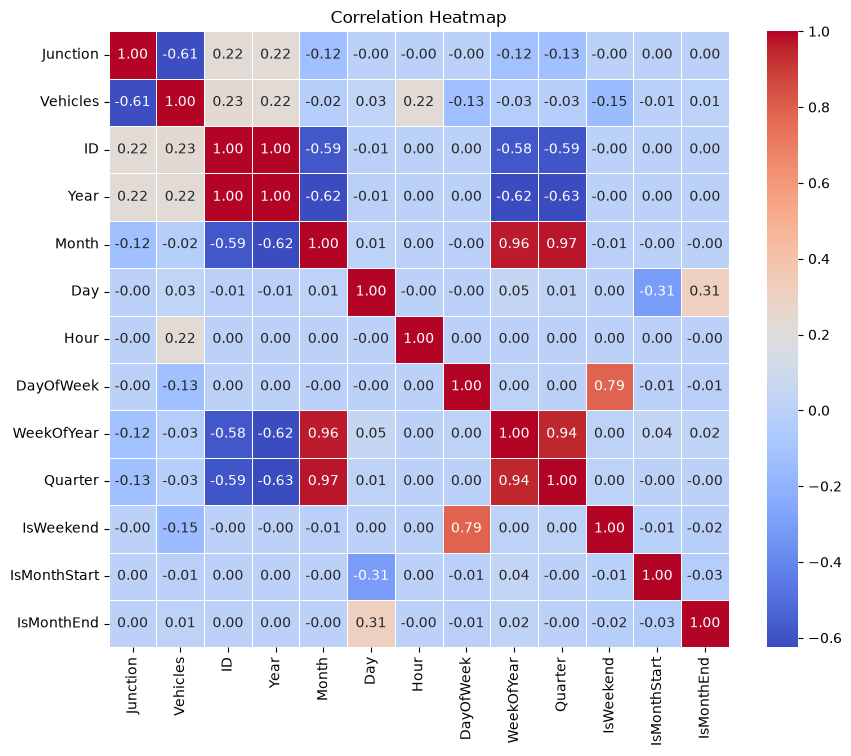

In [57]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

In [58]:
# ======================================
# Phase 6 : Data Preprocessing
# ======================================

# ======================================
# Step 32 : Check Current Columns
# ======================================

print("Current Columns:\n")

print(train_df.columns.tolist())

Current Columns:

['DateTime', 'Junction', 'Vehicles', 'ID', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek', 'DayName', 'WeekOfYear', 'Quarter', 'IsWeekend', 'IsMonthStart', 'IsMonthEnd']


In [61]:
# ======================================
# Step 33 : Drop Unnecessary Columns
# ======================================

train_model_df = train_df.drop(
    columns=[
        "DateTime",
        "DayName",
        "ID"
    ]
)

test_model_df = test_df.drop(
    columns=[
        "DateTime",
        "DayName",
        "ID"
    ]
)

In [62]:
print("Training Columns\n")
print(train_model_df.columns.tolist())

print("\nTesting Columns\n")
print(test_model_df.columns.tolist())

Training Columns

['Junction', 'Vehicles', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek', 'WeekOfYear', 'Quarter', 'IsWeekend', 'IsMonthStart', 'IsMonthEnd']

Testing Columns

['Junction', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek', 'WeekOfYear', 'Quarter', 'IsWeekend', 'IsMonthStart', 'IsMonthEnd']


In [63]:
# ======================================
# Phase 7 : Machine Learning
# ======================================

# ======================================
# Step 35 : Separate Features and Target
# ======================================

# Input Features
X = train_model_df.drop(columns=["Vehicles"])

# Target Variable
y = train_model_df["Vehicles"]

# Test Features
X_test = test_model_df


In [64]:
print("X Shape :", X.shape)
print("y Shape :", y.shape)
print("X_test Shape :", X_test.shape)

X Shape : (48120, 11)
y Shape : (48120,)
X_test Shape : (11808, 11)


In [65]:
print("Feature Columns:\n")

print(X.columns.tolist())

Feature Columns:

['Junction', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek', 'WeekOfYear', 'Quarter', 'IsWeekend', 'IsMonthStart', 'IsMonthEnd']


In [66]:
# ======================================
# Step 38 : Train-Test Split
# ======================================

from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [67]:
print("X_train :", X_train.shape)
print("X_valid :", X_valid.shape)

print("y_train :", y_train.shape)
print("y_valid :", y_valid.shape)

X_train : (38496, 11)
X_valid : (9624, 11)
y_train : (38496,)
y_valid : (9624,)


In [68]:
# ======================================
# Phase 8 : Model Training
# ======================================

# ======================================
# Step 40 : Import Linear Regression
# ======================================

from sklearn.linear_model import LinearRegression

In [69]:
# ======================================
# Step 41 : Create Linear Regression Model
# ======================================

lr_model = LinearRegression()

In [70]:
# ======================================
# Step 42 : Train the Model
# ======================================

lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](11,)","[-15.09, 17.04, 1.42,..., -6.3 , 0.28, -0.25]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](11,)","['Junction','Year','Month',...,'IsWeekend','IsMonthStart','IsMonthEnd']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3.432e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(11)


In [71]:
# ======================================
# Step 43 : Predict on Validation Set
# ======================================

y_pred = lr_model.predict(X_valid)

In [72]:
# ======================================
# Step 44 : Compare Predictions
# ======================================

comparison_df = X_valid.copy()

comparison_df["Actual"] = y_valid.values
comparison_df["Predicted"] = y_pred

comparison_df[["Actual", "Predicted"]].head(10)

,Actual,Predicted
24632,9,27.920877
36428,97,9.882965
42150,13,20.195163
23885,11,25.396235
2174,24,28.291848
34702,14,14.559422
39656,15,16.784375
40458,15,17.333264
21611,13,25.059819
31330,42,1.867010


In [73]:
# ======================================
# Step 45 : Import Metrics
# ======================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [74]:
# ======================================
# Step 46 : Evaluate Model
# ======================================

mae = mean_absolute_error(y_valid, y_pred)

mse = mean_squared_error(y_valid, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_valid, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 9.5791
MSE  : 161.0689
RMSE : 12.6913
R²   : 0.6048


In [75]:
# ======================================
# Step 47 : Import Decision Tree
# ======================================

from sklearn.tree import DecisionTreeRegressor

In [76]:
# ======================================
# Step 48 : Create Decision Tree Model
# ======================================

dt_model = DecisionTreeRegressor(
    random_state=42
)

In [77]:
# ======================================
# Step 49 : Train Decision Tree
# ======================================

dt_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [78]:
# ======================================
# Step 50 : Predict
# ======================================

dt_pred = dt_model.predict(X_valid)

In [79]:
# ======================================
# Step 51 : Evaluation
# ======================================

dt_mae = mean_absolute_error(y_valid, dt_pred)
dt_mse = mean_squared_error(y_valid, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_valid, dt_pred)

print(f"Decision Tree MAE  : {dt_mae:.4f}")
print(f"Decision Tree MSE  : {dt_mse:.4f}")
print(f"Decision Tree RMSE : {dt_rmse:.4f}")
print(f"Decision Tree R²   : {dt_r2:.4f}")

Decision Tree MAE  : 3.0593
Decision Tree MSE  : 20.7075
Decision Tree RMSE : 4.5505
Decision Tree R²   : 0.9492


In [80]:
# ======================================
# Step 52 : Import Random Forest
# ======================================

from sklearn.ensemble import RandomForestRegressor

In [81]:
# ======================================
# Step 53 : Create Random Forest Model
# ======================================

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [82]:
# ======================================
# Step 54 : Train Random Forest
# ======================================

rf_model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [83]:
# ======================================
# Step 55 : Predict
# ======================================

rf_pred = rf_model.predict(X_valid)

In [84]:
# ======================================
# Step 56 : Evaluation
# ======================================

rf_mae = mean_absolute_error(y_valid, rf_pred)
rf_mse = mean_squared_error(y_valid, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_valid, rf_pred)

print(f"Random Forest MAE  : {rf_mae:.4f}")
print(f"Random Forest MSE  : {rf_mse:.4f}")
print(f"Random Forest RMSE : {rf_rmse:.4f}")
print(f"Random Forest R²   : {rf_r2:.4f}")

Random Forest MAE  : 2.3807
Random Forest MSE  : 12.5409
Random Forest RMSE : 3.5413
Random Forest R²   : 0.9692


In [85]:
# ======================================
# Step 57 : Import XGBoost
# ======================================

from xgboost import XGBRegressor

In [86]:
# ======================================
# Step 58 : Create XGBoost Model
# ======================================

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    objective="reg:squarederror"
)

In [87]:
# ======================================
# Step 59 : Train XGBoost
# ======================================

xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [88]:
# ======================================
# Step 60 : Predict
# ======================================

xgb_pred = xgb_model.predict(X_valid)

In [89]:
# ======================================
# Step 61 : Evaluate XGBoost
# ======================================

xgb_mae = mean_absolute_error(y_valid, xgb_pred)
xgb_mse = mean_squared_error(y_valid, xgb_pred)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_valid, xgb_pred)

print(f"XGBoost MAE  : {xgb_mae:.4f}")
print(f"XGBoost MSE  : {xgb_mse:.4f}")
print(f"XGBoost RMSE : {xgb_rmse:.4f}")
print(f"XGBoost R²   : {xgb_r2:.4f}")

XGBoost MAE  : 2.8730
XGBoost MSE  : 23.7468
XGBoost RMSE : 4.8731
XGBoost R²   : 0.9417


In [90]:
# ======================================
# Phase 9 : Final Model Training
# ======================================

# ======================================
# Step 62 : Train Final Random Forest
# ======================================

final_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X, y)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [91]:
# ======================================
# Step 63 : Predict Test Data
# ======================================

test_predictions = final_model.predict(X_test)

In [92]:
# ======================================
# Step 64 : View Predictions
# ======================================

print(test_predictions[:10])

[68.52 58.11 46.33 38.13 32.86 32.16 35.34 35.86 39.39 43.5 ]


In [93]:
# ======================================
# Phase 10 : Create Submission File
# ======================================

submission = test_df.copy()

submission["Vehicles"] = test_predictions

submission.head()

,DateTime,Junction,ID,Year,Month,Day,Hour,DayOfWeek,DayName,WeekOfYear,Quarter,IsWeekend,IsMonthStart,IsMonthEnd,Vehicles
0,2017-07-01 00:00:00,1,20170701001,2017,7,1,0,5,Saturday,26,3,1,1,0,68.52
1,2017-07-01 01:00:00,1,20170701011,2017,7,1,1,5,Saturday,26,3,1,1,0,58.11
2,2017-07-01 02:00:00,1,20170701021,2017,7,1,2,5,Saturday,26,3,1,1,0,46.33
3,2017-07-01 03:00:00,1,20170701031,2017,7,1,3,5,Saturday,26,3,1,1,0,38.13
4,2017-07-01 04:00:00,1,20170701041,2017,7,1,4,5,Saturday,26,3,1,1,0,32.86


In [94]:
# ======================================
# Step 66 : Save Submission
# ======================================

submission = submission[
    [
        "ID",
        "Vehicles"
    ]
]

submission.head()

,ID,Vehicles
0,20170701001,68.52
1,20170701011,58.11
2,20170701021,46.33
3,20170701031,38.13
4,20170701041,32.86


In [95]:
# ======================================
# Step 67 : Save CSV
# ======================================

submission.to_csv(
    "../outputs/submission.csv",
    index=False
)

print("Submission file saved successfully!")

Submission file saved successfully!


In [96]:
# ======================================
# Phase 11 : Save Model
# ======================================

import joblib

joblib.dump(
    final_model,
    "../models/random_forest.pkl"
)

print("Model saved successfully!")

Model saved successfully!
